# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [1]:
import random

class Card:
    def __init__(self, rank, suit):
        self.rank = rank
        self.suit = suit

    def value(self):
        if self.rank in ['J', 'Q', 'K']:
            return 10
        elif self.rank == 'A':
            return 11
        else:
            return int(self.rank)

    def __str__(self):
        return f"{self.rank}{self.suit}"


class Deck:
    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.cards = []
        self.cut_card_index = None
        self.cut_card_reached = False
        self.build()
        self.shuffle()

    def build(self):
        suits = ['H', 'D', 'C', 'S']
        ranks = ['2','3','4','5','6','7','8','9','10','J','Q','K','A']

        self.cards = []
        for _ in range(self.num_decks):
            for suit in suits:
                for rank in ranks:
                    self.cards.append(Card(rank, suit))

    def shuffle(self):
        random.shuffle(self.cards)

        penetration = int(len(self.cards) * 0.75)
        self.cut_card_index = random.randint(penetration, len(self.cards)-1)

    def draw(self):
        if len(self.cards) == 0:
            raise ValueError("No cards left")

        card = self.cards.pop(0)

        if len(self.cards) == self.cut_card_index:
            self.cut_card_reached = True

        return card

    def cards_left(self):
        return len(self.cards)

In [2]:
print("Deck:")
deck = Deck(6)

print("\nTotal cards:", deck.cards_left())

print("\nDrawing 5 cards:")
for _ in range(5):
    print(deck.draw())

print("\nSimulating until cut card is reached:-")
while not deck.cut_card_reached:
    deck.draw()

print("Cut card reached! Shuffle before next round.")

Deck:

Total cards: 312

Drawing 5 cards:
2D
8S
5C
5H
JD

Simulating until cut card is reached:-
Cut card reached! Shuffle before next round.


2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

In [3]:
class Card:
    def __init__(self, rank, suit):
        self.rank = rank
        self.suit = suit
    def value(self):
        pass
    def __str__(self):
        pass

class Deck:
    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.cards = []
        self.cut_card_index = None
        self.cut_card_reached = False
    def build(self):
        pass
    def shuffle(self):
        pass
    def draw(self):
        pass
    def cards_left(self):
        pass

class Hand:
    def __init__(self):
        self.cards = []
    def add_card(self, card):
        pass
    def value(self):
        pass
    def is_bust(self):
        pass

class Player:
    def __init__(self, chips=100):
        self.hand = Hand()
        self.chips = chips
        self.strategy = None
    def bet(self):
        pass
    def hit(self):
        pass
    def stand(self):
        pass
    def decide(self):
        pass
        
class Dealer(Player):
    def __init__(self):
        super().__init__()
    def play(self):
        pass

class Game:
    def __init__(self, num_players=1):
        self.deck = Deck()
        self.players = [Player() for _ in range(num_players)]
        self.dealer = Dealer()
    def deal(self):
        pass
    def play_round(self):
        pass
    def resolve(self):
        pass

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [5]:
import random

class Card:
    def __init__(self, rank, suit):
        self.rank = rank
        self.suit = suit

    def value(self):
        if self.rank in ['J','Q','K']:
            return 10
        elif self.rank == 'A':
            return 11
        return int(self.rank)

    def __str__(self):
        return f"{self.rank}{self.suit}"


class Deck:
    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.cards = []
        self.cut_card_index = None
        self.cut_card_reached = False
        self.build()
        self.shuffle()

    def build(self):
        suits = ['H','D','C','S']
        ranks = ['2','3','4','5','6','7','8','9','10','J','Q','K','A']
        self.cards = [Card(rank,suit) for _ in range(self.num_decks) for suit in suits for rank in ranks]

    def shuffle(self):
        random.shuffle(self.cards)
        self.cut_card_reached = False
        penetration = int(len(self.cards)*0.75)
        self.cut_card_index = random.randint(penetration, len(self.cards)-1)

    def draw(self):
        card = self.cards.pop(0)
        if len(self.cards) <= self.cut_card_index:
            self.cut_card_reached = True
        return card


class Hand:
    def __init__(self):
        self.cards = []

    def add_card(self, card):
        self.cards.append(card)

    def value(self):
        total = 0
        aces = 0

        for c in self.cards:
            if c.rank == 'A':
                aces += 1
            total += c.value()

        while total > 21 and aces:
            total -= 10
            aces -= 1

        return total

    def is_bust(self):
        return self.value() > 21

    def __str__(self):
        return " ".join(str(c) for c in self.cards)


class Player:
    def __init__(self, chips=100):
        self.hand = Hand()
        self.chips = chips

    def bet(self):
        while True:
            try:
                bet = int(input(f"You have {self.chips} chips. Enter bet: "))
                if 0 < bet <= self.chips:
                    return bet
            except:
                pass
            print("Invalid bet.")

    def hit(self, deck):
        self.hand.add_card(deck.draw())

    def play(self, deck):
        while True:
            print(f"Your hand: {self.hand} (value: {self.hand.value()})")
            if self.hand.is_bust():
                print("You busted!")
                return

            move = input("Hit or stand? (h/s): ").lower()
            if move == 'h':
                self.hit(deck)
            else:
                return


class Dealer:
    def __init__(self):
        self.hand = Hand()

    def reset_hand(self):
        self.hand = Hand()

    def hit(self, deck):
        self.hand.add_card(deck.draw())

    def play(self, deck):
        print("\nDealer's turn:")
        print(f"Dealer hand: {self.hand} ({self.hand.value()})")

        while self.hand.value() < 17:
            self.hit(deck)
            print(f"Dealer draws: {self.hand.cards[-1]}")

        print(f"Dealer stands with {self.hand.value()}")

class AutoPlayer:
    def __init__(self, name="AutoPlayer", chips=100):
        self.name = name
        self.hand = Hand()
        self.chips = chips

    def reset_hand(self):
        self.hand = Hand()

    def hit(self, deck):
        self.hand.add_card(deck.draw())

    def play(self, deck):
        print(f"\n{self.name}'s turn:")
        print(f"{self.name} hand: {self.hand} (value: {self.hand.value()})")

        while self.hand.value() < 17:
            self.hit(deck)
            print(f"{self.name} draws: {self.hand.cards[-1]}")

        print(f"{self.name} stands with {self.hand.value()}")

class Game:
    def __init__(self, num_players=3):
        self.deck = Deck()
        self.players = [AutoPlayer(f"Player{i+1}") for i in range(num_players)]
        self.dealer = Dealer()

    def deal(self):
        self.dealer.reset_hand()
        for p in self.players:
            p.reset_hand()
    
        for _ in range(2):
            for p in self.players:
                p.hit(self.deck)
            self.dealer.hit(self.deck)

    def play_round(self):
        if self.deck.cut_card_reached:
            print("\nReshuffling deck...\n")
            self.deck = Deck()
    
        self.deal()
    
        print(f"\nDealer shows: {self.dealer.hand.cards[0]}")
    
        for p in self.players:
            p.play(self.deck)
    
        self.dealer.play(self.deck)
    
        print("\n--- Results ---")
        dealer_val = self.dealer.hand.value()
    
        for p in self.players:
            player_val = p.hand.value()
    
            print(f"{p.name}: {player_val} vs Dealer: {dealer_val}")
    
            if p.hand.is_bust():
                print(f"{p.name} busts → loses")
            elif self.dealer.hand.is_bust() or player_val > dealer_val:
                print(f"{p.name} wins")
            elif player_val < dealer_val:
                print(f"{p.name} loses")
            else:
                print(f"{p.name} pushes")
            
    def resolve(self, bet):
        player_val = self.player.hand.value()
        dealer_val = self.dealer.hand.value()

        print(f"\nFinal Hands:")
        print(f"Player: {self.player.hand} ({player_val})")
        print(f"Dealer: {self.dealer.hand} ({dealer_val})")

        if self.player.hand.is_bust():
            print("You lose!")
            self.player.chips -= bet
        elif self.dealer.hand.is_bust() or player_val > dealer_val:
            print("You win!")
            self.player.chips += bet
        elif player_val < dealer_val:
            print("You lose!")
            self.player.chips -= bet
        else:
            print("Push (tie).")

5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [6]:
game = Game(num_players=3)

for i in range(3):
    print(f"\n========== ROUND {i+1} ==========")
    game.play_round()


========== ROUND 1 ==========

Dealer shows: 9C

Player1's turn:
Player1 hand: 7C 7D (value: 14)
Player1 draws: 8D
Player1 stands with 22

Player2's turn:
Player2 hand: AS 7C (value: 18)
Player2 stands with 18

Player3's turn:
Player3 hand: JH 3C (value: 13)
Player3 draws: 6H
Player3 stands with 19

Dealer's turn:
Dealer hand: 9C 8C (17)
Dealer stands with 17

--- Results ---
Player1: 22 vs Dealer: 17
Player1 busts → loses
Player2: 18 vs Dealer: 17
Player2 wins
Player3: 19 vs Dealer: 17
Player3 wins

========== ROUND 2 ==========

Dealer shows: 3D

Player1's turn:
Player1 hand: 2C 3H (value: 5)
Player1 draws: 3S
Player1 draws: 9S
Player1 stands with 17

Player2's turn:
Player2 hand: 6H 3D (value: 9)
Player2 draws: QD
Player2 stands with 19

Player3's turn:
Player3 hand: 9D 2S (value: 11)
Player3 draws: 7H
Player3 stands with 18

Dealer's turn:
Dealer hand: 3D QC (13)
Dealer draws: 5D
Dealer stands with 18

--- Results ---
Player1: 17 vs Dealer: 18
Player1 loses
Player2: 19 vs Dealer: 

6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [8]:
class CountingPlayer:
    def __init__(self, name="Counter", threshold=0):
        self.name = name
        self.hand = Hand()
        self.running_count = 0
        self.threshold = threshold

    def reset_hand(self):
        self.hand = Hand()

    def card_value(self, card):
        if card.rank in ['2','3','4','5','6']:
            return 1
        elif card.rank in ['7','8','9']:
            return 0
        else:
            return -1

    def observe(self, card):
        self.running_count += self.card_value(card)

    def hit(self, deck):
        card = deck.draw()
        self.hand.add_card(card)
        self.observe(card)

    def play(self, deck):
        print(f"\n{self.name}'s turn (count={self.running_count}):")
        print(f"{self.name} hand: {self.hand} ({self.hand.value()})")

        while True:
            if self.hand.is_bust():
                print(f"{self.name} busts!")
                return

            if self.running_count < self.threshold:
                print(f"{self.name} hits")
                self.hit(deck)
                print(f"{self.name} draws: {self.hand.cards[-1]}")
            else:
                print(f"{self.name} stands")
                return

class Dealer:
    def __init__(self):
        self.hand = Hand()

    def reset_hand(self):
        self.hand = Hand()

    def play(self, deck, players):
        print("\nDealer's turn:")
        print(f"Dealer hand: {self.hand} ({self.hand.value()})")

        while self.hand.value() < 17:
            card = deck.draw()
            self.hand.add_card(card)
            print(f"Dealer draws: {card}")

            # players observe dealer cards
            for p in players:
                if hasattr(p, "observe"):
                    p.observe(card)

        print(f"Dealer stands with {self.hand.value()}")

def new_deal(self):
    self.dealer.reset_hand()
    for p in self.players:
        p.reset_hand()

    for _ in range(2):
        for p in self.players:
            card = self.deck.draw()
            p.hand.add_card(card)

            for other in self.players:
                if hasattr(other, "observe"):
                    other.observe(card)

        card = self.deck.draw()
        self.dealer.hand.add_card(card)

        for p in self.players:
            if hasattr(p, "observe"):
                p.observe(card)

def new_play_round(self):
    if self.deck.cut_card_reached:
        print("\nReshuffling deck...\n")
        self.deck = Deck()

    self.deal()

    print(f"\nDealer shows: {self.dealer.hand.cards[0]}")

    for p in self.players:
        p.play(self.deck)

    self.dealer.play(self.deck, self.players)

    print("\n--- Results ---")
    dealer_val = self.dealer.hand.value()

    for p in self.players:
        player_val = p.hand.value()

        print(f"{p.name}: {player_val} vs Dealer: {dealer_val}")

        if p.hand.is_bust():
            print(f"{p.name} loses")
        elif self.dealer.hand.is_bust() or player_val > dealer_val:
            print(f"{p.name} wins")
        elif player_val < dealer_val:
            print(f"{p.name} loses")
        else:
            print(f"{p.name} pushes")

Game.deal = new_deal
Game.play_round = new_play_round

game = Game()

game.players = [
    AutoPlayer("Basic"),
    CountingPlayer("Counter", threshold=0)
]

for i in range(3):
    print(f"\n========== ROUND {i+1} ==========")
    game.play_round()


========== ROUND 1 ==========

Dealer shows: QD

Basic's turn:
Basic hand: 9C KS (value: 19)
Basic stands with 19

Counter's turn (count=-2):
Counter hand: 8H QC (18)
Counter hits
Counter draws: 9H
Counter busts!

Dealer's turn:
Dealer hand: QD 5C (15)
Dealer draws: 6S
Dealer stands with 21

--- Results ---
Basic: 19 vs Dealer: 21
Basic loses
Counter: 27 vs Dealer: 21
Counter loses

========== ROUND 2 ==========

Dealer shows: QC

Basic's turn:
Basic hand: 3S 7D (value: 10)
Basic draws: QC
Basic stands with 20

Counter's turn (count=-2):
Counter hand: AH 10S (21)
Counter hits
Counter draws: QD
Counter hits
Counter draws: JC
Counter busts!

Dealer's turn:
Dealer hand: QC 2C (12)
Dealer draws: 2C
Dealer draws: 3C
Dealer stands with 17

--- Results ---
Basic: 20 vs Dealer: 17
Basic wins
Counter: 31 vs Dealer: 17
Counter loses

========== ROUND 3 ==========

Reshuffling deck...


Dealer shows: 6D

Basic's turn:
Basic hand: 10H 3C (value: 13)
Basic draws: 3H
Basic draws: 6H
Basic stands wi

7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [10]:
import random

VERBOSE = False  

class CountingPlayer:
    def __init__(self, name="Counter", threshold=0, chips=100):
        self.name = name
        self.hand = Hand()
        self.running_count = 0
        self.threshold = threshold
        self.chips = chips

    def reset_hand(self):
        self.hand = Hand()

    def card_value(self, card):
        if card.rank in ['2','3','4','5','6']:
            return 1
        elif card.rank in ['7','8','9']:
            return 0
        else:
            return -1

    def observe(self, card):
        self.running_count += self.card_value(card)

    def hit(self, deck):
        card = deck.draw()
        self.hand.add_card(card)
        self.observe(card)

    def play(self, deck):
        while True:
            if self.hand.is_bust():
                return

            if self.running_count < self.threshold:
                self.hit(deck)
            else:
                return

class AutoPlayer:
    def __init__(self, name, chips=100):
        self.name = name
        self.hand = Hand()
        self.chips = chips

    def reset_hand(self):
        self.hand = Hand()

    def hit(self, deck):
        self.hand.add_card(deck.draw())

    def play(self, deck):
        while self.hand.value() < 17:
            self.hit(deck)

class Dealer:
    def __init__(self):
        self.hand = Hand()

    def reset_hand(self):
        self.hand = Hand()

    def play(self, deck, players):
        while self.hand.value() < 17:
            card = deck.draw()
            self.hand.add_card(card)

            for p in players:
                if hasattr(p, "observe"):
                    p.observe(card)

class Game:
    def __init__(self):
        self.deck = Deck()
        self.players = []
        self.dealer = Dealer()

    def deal(self):
        self.dealer.reset_hand()
        for p in self.players:
            p.reset_hand()

        for _ in range(2):
            for p in self.players:
                card = self.deck.draw()
                p.hand.add_card(card)

                for other in self.players:
                    if hasattr(other, "observe"):
                        other.observe(card)

            card = self.deck.draw()
            self.dealer.hand.add_card(card)

            for p in self.players:
                if hasattr(p, "observe"):
                    p.observe(card)

    def play_round(self, bet=10):
        if self.deck.cut_card_reached:
            self.deck = Deck()

        self.deal()

        for p in self.players:
            p.play(self.deck)

        self.dealer.play(self.deck, self.players)

        dealer_val = self.dealer.hand.value()

        for p in self.players:
            player_val = p.hand.value()

            if p.hand.is_bust():
                p.chips -= bet
            elif self.dealer.hand.is_bust() or player_val > dealer_val:
                p.chips += bet
            elif player_val < dealer_val:
                p.chips -= bet

game = Game()

counter = CountingPlayer("Counter", threshold=0, chips=100)

game.players = [
    counter,
    AutoPlayer("P1", 100),
    AutoPlayer("P2", 100),
    AutoPlayer("P3", 100)
]

rounds = 50
bet = 10

for i in range(rounds):
    if counter.chips <= 0:
        print(f"Counter went broke at round {i}")
        break

    game.play_round(bet)

print("\n===== RESULTS =====")
print(f"Rounds played: {i+1}")
print(f"Counter final chips: {counter.chips}")
print(f"Counter winnings: {counter.chips - 100}")

Counter went broke at round 12

===== RESULTS =====
Rounds played: 13
Counter final chips: 0
Counter winnings: -100


8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


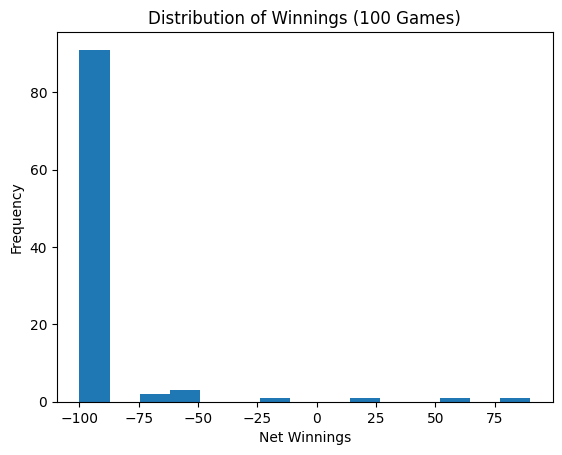

===== RESULTS =====
Average winnings per game: -92.50
Average winnings per round: -1.8500
Standard deviation: 29.21
Probability of net win: 0.03
Probability of net loss: 0.97


In [11]:
import matplotlib.pyplot as plt
import statistics

NUM_GAMES = 100
ROUNDS_PER_GAME = 50
START_CHIPS = 100
BET = 10

winnings = []

for g in range(NUM_GAMES):
    game = Game()

    counter = CountingPlayer("Counter", threshold=0, chips=START_CHIPS)

    game.players = [
        counter,
        AutoPlayer("P1", START_CHIPS),
        AutoPlayer("P2", START_CHIPS),
        AutoPlayer("P3", START_CHIPS)
    ]

    for r in range(ROUNDS_PER_GAME):
        if counter.chips <= 0:
            break
        game.play_round(BET)

    winnings.append(counter.chips - START_CHIPS)


plt.hist(winnings, bins=15)
plt.title("Distribution of Winnings (100 Games)")
plt.xlabel("Net Winnings")
plt.ylabel("Frequency")
plt.show()


avg_winnings = sum(winnings) / len(winnings)
avg_per_round = avg_winnings / ROUNDS_PER_GAME
std_dev = statistics.stdev(winnings)

prob_win = sum(1 for w in winnings if w > 0) / len(winnings)
prob_loss = sum(1 for w in winnings if w < 0) / len(winnings)

print("===== RESULTS =====")
print(f"Average winnings per game: {avg_winnings:.2f}")
print(f"Average winnings per round: {avg_per_round:.4f}")
print(f"Standard deviation: {std_dev:.2f}")
print(f"Probability of net win: {prob_win:.2f}")
print(f"Probability of net loss: {prob_loss:.2f}")

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

===== THRESHOLD RESULTS =====
Threshold -5:
  Avg winnings: -84.30
  Avg per round: -1.6860
  Std dev: 34.94

Threshold -2:
  Avg winnings: -92.20
  Avg per round: -1.8440
  Std dev: 20.72

Threshold 0:
  Avg winnings: -91.20
  Avg per round: -1.8240
  Std dev: 26.72

Threshold 2:
  Avg winnings: -97.00
  Avg per round: -1.9400
  Std dev: 11.76

Threshold 5:
  Avg winnings: -99.90
  Avg per round: -1.9980
  Std dev: 1.00

Best threshold: -5
Best average winnings: -84.30


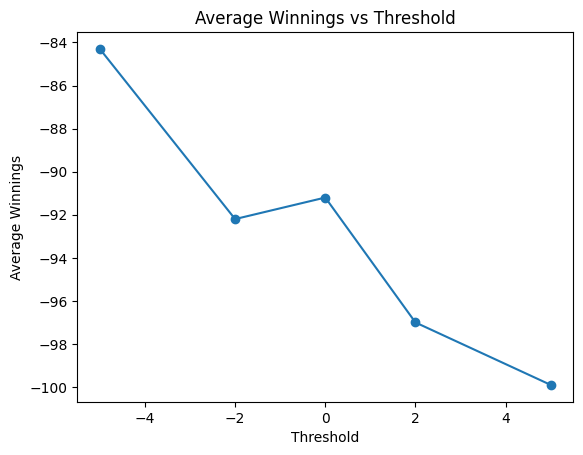

In [12]:
import matplotlib.pyplot as plt
import statistics

thresholds = [-5, -2, 0, 2, 5]
NUM_GAMES = 100
ROUNDS_PER_GAME = 50
START_CHIPS = 100
BET = 10

results = {}

for t in thresholds:
    winnings = []

    for g in range(NUM_GAMES):
        game = Game()

        counter = CountingPlayer("Counter", threshold=t, chips=START_CHIPS)

        game.players = [
            counter,
            AutoPlayer("P1", START_CHIPS),
            AutoPlayer("P2", START_CHIPS),
            AutoPlayer("P3", START_CHIPS)
        ]

        for r in range(ROUNDS_PER_GAME):
            if counter.chips <= 0:
                break
            game.play_round(BET)

        winnings.append(counter.chips - START_CHIPS)

    avg = sum(winnings) / len(winnings)
    std = statistics.stdev(winnings)

    results[t] = {
        "avg": avg,
        "std": std,
        "per_round": avg / ROUNDS_PER_GAME
    }


print("===== THRESHOLD RESULTS =====")
for t in thresholds:
    print(f"Threshold {t}:")
    print(f"  Avg winnings: {results[t]['avg']:.2f}")
    print(f"  Avg per round: {results[t]['per_round']:.4f}")
    print(f"  Std dev: {results[t]['std']:.2f}")
    print()


best_threshold = max(results, key=lambda t: results[t]["avg"])

print(f"Best threshold: {best_threshold}")
print(f"Best average winnings: {results[best_threshold]['avg']:.2f}")


x = list(results.keys())
y = [results[t]["avg"] for t in x]

plt.plot(x, y, marker='o')
plt.title("Average Winnings vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Average Winnings")
plt.show()

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

===== STRATEGY COMPARISON =====
Basic Counting Avg: -95.00, Std: 18.45
True Count Avg: -97.80, Std: 11.60


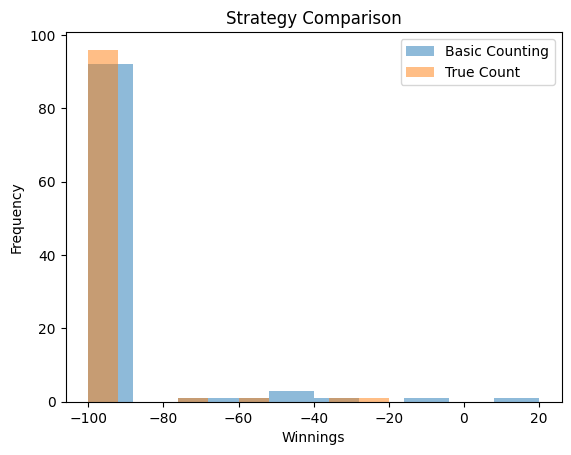

In [13]:
import statistics
import matplotlib.pyplot as plt

class TrueCountPlayer:
    def __init__(self, name="TrueCounter", threshold=0, chips=100):
        self.name = name
        self.hand = Hand()
        self.running_count = 0
        self.threshold = threshold
        self.chips = chips

    def reset_hand(self):
        self.hand = Hand()

    def card_value(self, card):
        if card.rank in ['2','3','4','5','6']:
            return 1
        elif card.rank in ['7','8','9']:
            return 0
        else:
            return -1

    def observe(self, card):
        self.running_count += self.card_value(card)

    def true_count(self, deck):
        decks_remaining = max(len(deck.cards) / 52, 1)
        return self.running_count / decks_remaining

    def hit(self, deck):
        card = deck.draw()
        self.hand.add_card(card)
        self.observe(card)

    def play(self, deck):
        while True:
            if self.hand.is_bust():
                return

            tc = self.true_count(deck)

            if tc < self.threshold:
                self.hit(deck)
            else:
                return


NUM_GAMES = 100
ROUNDS = 50
START = 100
BET = 10

def simulate(player_class):
    winnings = []

    for _ in range(NUM_GAMES):
        game = Game()

        player = player_class(chips=START)

        game.players = [
            player,
            AutoPlayer("P1", START),
            AutoPlayer("P2", START),
            AutoPlayer("P3", START)
        ]

        for _ in range(ROUNDS):
            if player.chips <= 0:
                break
            game.play_round(BET)

        winnings.append(player.chips - START)

    return winnings


basic_results = simulate(lambda chips: CountingPlayer("BasicCounter", threshold=0, chips=chips))
true_results = simulate(lambda chips: TrueCountPlayer("TrueCounter", threshold=0, chips=chips))


basic_avg = sum(basic_results) / len(basic_results)
true_avg = sum(true_results) / len(true_results)

basic_std = statistics.stdev(basic_results)
true_std = statistics.stdev(true_results)

print("===== STRATEGY COMPARISON =====")
print(f"Basic Counting Avg: {basic_avg:.2f}, Std: {basic_std:.2f}")
print(f"True Count Avg: {true_avg:.2f}, Std: {true_std:.2f}")

plt.hist(basic_results, alpha=0.5, label="Basic Counting")
plt.hist(true_results, alpha=0.5, label="True Count")
plt.legend()
plt.title("Strategy Comparison")
plt.xlabel("Winnings")
plt.ylabel("Frequency")
plt.show()